<a href="https://www.kaggle.com/code/alpaypasali/russian-handwritten-letter-recognition-with-cnn?scriptVersionId=309199518" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🔤 Russian Handwritten Letter Recognition | CNN Image Classification

In this notebook, I built a **Convolutional Neural Network (CNN)** model to recognize
handwritten letters from the Russian alphabet.

---

## 📂 Dataset

**Russian Handwritten Letters** dataset was used.
- **14,190 images** in total
- **33 classes** (one for each letter in the Russian alphabet)
- Each image is **32×32 pixels** in RGB format

---

## 🔄 Data Preprocessing

### 1. Train / Validation / Test Split
The dataset was divided into 3 parts:
- **70%** → Training
- **15%** → Validation
- **15%** → Test

The `stratify` parameter was used to ensure a **proportional distribution** across all classes.

### 2. Normalization
Pixel values were scaled from `[0, 255]` to `[0.0, 1.0]`:
```python
img_array = img_array / 255.0
```

### 3. One-Hot Encoding
Class labels (1–33) were first shifted to **zero-based** indexing (`-1`),
then converted to categorical format using `to_categorical`.

---

## 🧠 CNN Architecture

The model consists of 3 **Conv2D + MaxPooling** blocks:

| Layer | Details |
|---|---|
| Conv2D | 32 filters, 3×3, ReLU |
| MaxPooling2D | 2×2 |
| Conv2D | 64 filters, 3×3, ReLU |
| MaxPooling2D | 2×2 |
| Conv2D | 128 filters, 3×3, ReLU |
| Flatten | — |
| Dense | 256 neurons, ReLU |
| Dense (output) | 33 neurons, Softmax |

### What is a CNN?

A CNN (Convolutional Neural Network) is a deep learning architecture specifically
designed for image recognition tasks.

- **Conv2D layers** → learn low-level features like edges, curves, and textures
- **MaxPooling** → reduces spatial dimensions, lowers computation and helps prevent overfitting
- **Flatten + Dense** → transforms learned features into class predictions
- **Softmax** → produces a probability distribution across all 33 classes

---

## ⚙️ Training Configuration

| Parameter | Value |
|---|---|
| Optimizer | Adam |
| Loss | Categorical Crossentropy |
| Metrics | Accuracy, AUC |
| Early Stopping | Monitors `val_loss`, patience = 10 |
| Model Checkpoint | Saves best model weights |

---

## 📊 Results

Predictions were visualized on a random sample from the test set.  
🟢 **Green** → Correct prediction  
🔴 **Red** → Wrong prediction

In [6]:
from glob import glob
import random, os, datetime
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, metrics
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models  import Sequential, load_model
from tensorflow.keras.metrics import Accuracy, AUC
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Input
from tensorflow.keras.metrics import AUC


from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split

In [7]:
def get_images_with_labels(root_dir, file_to_label, num_images=None):
    all_images = []
    for extension in ['*.jpg', '*.jpeg', '*.png']:
        all_images.extend(glob(os.path.join(root_dir, '**', extension), recursive=True))

    if num_images is not None:
        all_images = random.sample(all_images, min(num_images, len(all_images)))

    data = []
    for img_path in all_images:
        file_name = os.path.basename(img_path)
        label = file_to_label.get(file_name, None)
        data.append((img_path, label))

    return data

def display_images(data):
    plt.figure(figsize=(15, 6))

    for i, (img_path, label) in enumerate(data):
        img = image.load_img(img_path)
        img = image.img_to_array(img, dtype=np.uint8)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img.squeeze())
        plt.axis('off')
        plt.title(f'Label: {label}')

    plt.tight_layout()
    plt.show()


In [8]:
csv_path = "/kaggle/input/datasets/tatianasnwrt/russian-handwritten-letters/all_letters_info.csv"
df = pd.read_csv(csv_path)
file_to_label = dict(zip(df['file'], df['label']))
data = get_images_with_labels(
    "/kaggle/input/datasets/tatianasnwrt/russian-handwritten-letters/all_letters_image/all_letters_image",
    file_to_label,

)


14190


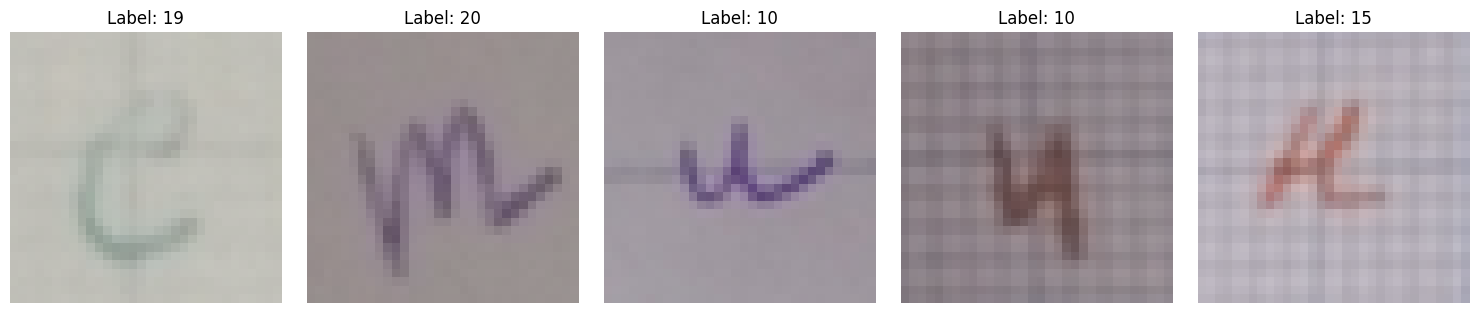

In [9]:
print(len(data))

display_images(data[0:5])

In [10]:
from sklearn.model_selection import train_test_split

image_paths = [d[0] for d in data]
labels = [d[1] for d in data]


X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, labels, test_size=0.30, random_state=42, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 9933, Val: 2128, Test: 2129


In [11]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


image_paths = [d[0] for d in data]
labels = [d[1] for d in data]

X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, labels, test_size=0.30, random_state=42, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


def load_and_preprocess(paths, labels, img_size=(32, 32)):
    X, y = [], []
    for path, label in zip(paths, labels):
        img = image.load_img(path, target_size=img_size)
        img_array = image.img_to_array(img) / 255.0
        X.append(img_array)
        y.append(label)
    return np.array(X), np.array(y)

X_train, y_train = load_and_preprocess(X_train, y_train)
X_val,   y_val   = load_and_preprocess(X_val,   y_val)
X_test,  y_test  = load_and_preprocess(X_test,  y_test)

print(X_train.shape)  # (n, 32, 32, 3)
print(X_train.max())  # 1.0

# 3. Label'ları 0-based'e çek (1-33 → 0-32)
y_train = y_train - 1
y_val   = y_val   - 1
y_test  = y_test  - 1

print(np.unique(y_train))  # 0'dan 32'ye gitmeli


y_train_cat = to_categorical(y_train, num_classes=33)
y_val_cat   = to_categorical(y_val,   num_classes=33)
y_test_cat  = to_categorical(y_test,  num_classes=33)

def prepare_datasets(X_train, X_val, y_train, y_val, batch_size=None):
    if batch_size is None:
        batch_size = len(X_train)
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    train_dataset = train_dataset.shuffle(buffer_size=len(X_train)).batch(batch_size)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
    val_dataset = val_dataset.batch(batch_size)
    return train_dataset, val_dataset

train_ds, val_ds = prepare_datasets(X_train, X_val, y_train_cat, y_val_cat, batch_size=32)

Train: 9933, Val: 2128, Test: 2129
(9933, 32, 32, 3)
1.0
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32]


2026-04-05 15:39:36.758967: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


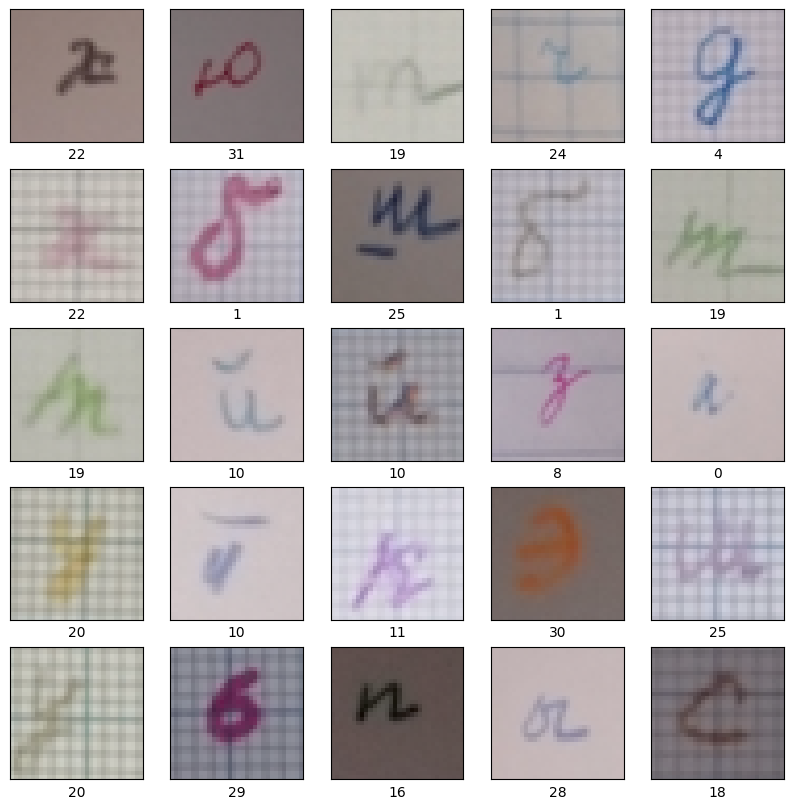

In [12]:
def show_random_examples(images, labels, num_examples=25, figsize=(10, 10)):
    indices = np.random.choice(len(images), num_examples, replace=False)
    plt.figure(figsize=figsize)
    for i, idx in enumerate(indices):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[idx], cmap='gray')
        plt.xlabel(labels[idx])
    plt.show()
    
    
show_random_examples(X_train, y_train)
 

In [13]:
model = Sequential([
    Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),   # Con2D → Conv2D
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),   # Con2D → Conv2D
    layers.MaxPooling2D((2,2)),                    # layer. → layers.

    layers.Conv2D(128, (3,3), activation='relu'),  # Con2D → Conv2D
    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dense(33, activation='softmax')         # Dens → Dense
])

metrics = [
    'accuracy',
    AUC(name='auc', multi_label=True)
]

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=metrics
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(   # ModelCheckPoint → ModelCheckpoint
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

In [14]:
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[early_stopping, model_checkpoint]  # chekpoint → checkpoint
)

Epoch 1/50
309/311 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0353 - auc: 0.5029 - loss: 3.4909
Epoch 1: val_loss improved from inf to 3.40374, saving model to best_model.h5


311/311 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.0354 - auc: 0.5033 - loss: 3.4906 - val_accuracy: 0.0432 - val_auc: 0.6385 - val_loss: 3.4037
Epoch 2/50
309/311 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0830 - auc: 0.6540 - loss: 3.3002
Epoch 2: val_loss improved from 3.40374 to 2.50552, saving model to best_model.h5


311/311 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.0836 - auc: 0.6548 - loss: 3.2980 - val_accuracy: 0.2749 - val_auc: 0.8710 - val_loss: 2.5055
Epoch 3/50
310/311 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3459 - auc: 0.8861 - loss: 2.2545
Epoch 3: val_loss improved from 2.50552 to 1.84934, saving model to best_model.h5


311/311 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.3462 - auc: 0.8862 - loss: 2.2536 - val_accuracy: 0.4657 - val_auc: 0.9277 - val_loss: 1.8493
Epoch 4/50
310/311 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4913 - auc: 0.9336 - loss: 1.7338
Epoch 4: val_loss improved from 1.84934 to 1.61223, saving model to best_model.h5


311/311 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.4915 - auc: 0.9337 - loss: 1.7334 - val_accuracy: 0.5315 - val_auc: 0.9454 - val_loss: 1.6122
Epoch 5/50
309/311 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5724 - auc: 0.9524 - loss: 1.4424
Epoch 5: val_loss improved from 1.61223 to 1.39449, saving model to best_model.h5


...

311/311 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.7612 - auc: 0.9842 - loss: 0.7872 - val_accuracy: 0.7265 - val_auc: 0.9762 - val_loss: 0.9313
Epoch 10/50
311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7972 - auc: 0.9866 - loss: 0.6746
Epoch 10: val_loss did not improve from 0.93131
311/311 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.7972 - auc: 0.9866 - loss: 0.6747 - val_accuracy: 0.7270 - val_auc: 0.9753 - val_loss: 0.9469
Epoch 11/50
309/311 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8220 - auc: 0.9897 - loss: 0.5825
Epoch 11: val_loss improved from 0.93131 to 0.86946, saving model to best_model.h5


311/311 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.8219 - auc: 0.9897 - loss: 0.5828 - val_accuracy: 0.7477 - val_auc: 0.9784 - val_loss: 0.8695
Epoch 12/50
310/311 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8421 - auc: 0.9903 - loss: 0.5188
Epoch 12: val_loss did not improve from 0.86946
311/311 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8421 - auc: 0.9903 - loss: 0.5188 - val_accuracy: 0.7472 - val_auc: 0.9765 - val_loss: 0.8834
Epoch 13/50
309/311 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8610 - auc: 0.9921 - loss: 0.4537
Epoch 13: val_loss improved from 0.86946 to 0.83645, saving model to best_model.h5


311/311 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8609 - auc: 0.9921 - loss: 0.4538 - val_accuracy: 0.7632 - val_auc: 0.9777 - val_loss: 0.8364
Epoch 14/50
310/311 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8727 - auc: 0.9927 - loss: 0.4113
Epoch 14: val_loss improved from 0.83645 to 0.79453, saving model to best_model.h5


311/311 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8727 - auc: 0.9927 - loss: 0.4114 - val_accuracy: 0.7740 - val_auc: 0.9789 - val_loss: 0.7945
Epoch 15/50
309/311 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8774 - auc: 0.9933 - loss: 0.3842
Epoch 15: val_loss did not improve from 0.79453
311/311 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8774 - auc: 0.9933 - loss: 0.3841 - val_accuracy: 0.7796 - val_auc: 0.9768 - val_loss: 0.8108
Epoch 16/50
309/311 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8997 - auc: 0.9956 - loss: 0.3143
Epoch 16: val_loss did not improve from 0.79453
311/311 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8997 - auc: 0.9956 - loss: 0.3144 - val_accuracy: 0.7570 - val_auc: 0.9739 - val_loss: 0.8819
Epoch 17/50
310/311 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9112 - auc: 0.9955 - loss: 0.2800
Epoch 17: val_loss did not improve from 0.79453
311/311 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9112 - auc: 0.9955 - loss: 0.2801 - val_accu

311/311 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9208 - auc: 0.9961 - loss: 0.2466 - val_accuracy: 0.7946 - val_auc: 0.9805 - val_loss: 0.7695
Epoch 19/50
310/311 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9348 - auc: 0.9969 - loss: 0.2145
Epoch 19: val_loss did not improve from 0.76945
311/311 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9347 - auc: 0.9969 - loss: 0.2146 - val_accuracy: 0.7871 - val_auc: 0.9712 - val_loss: 0.8802
Epoch 20/50
309/311 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9434 - auc: 0.9970 - loss: 0.1887
Epoch 20: val_loss did not improve from 0.76945
311/311 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9433 - auc: 0.9970 - loss: 0.1889 - val_accuracy: 0.7956 - val_auc: 0.9770 - val_loss: 0.7936
Epoch 21/50
311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9503 - auc: 0.9974 - loss: 0.1608
Epoch 21: val_loss did not improve from 0.76945
311/311 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9503 - auc: 0.9974 - loss: 0.1609 - val_accu

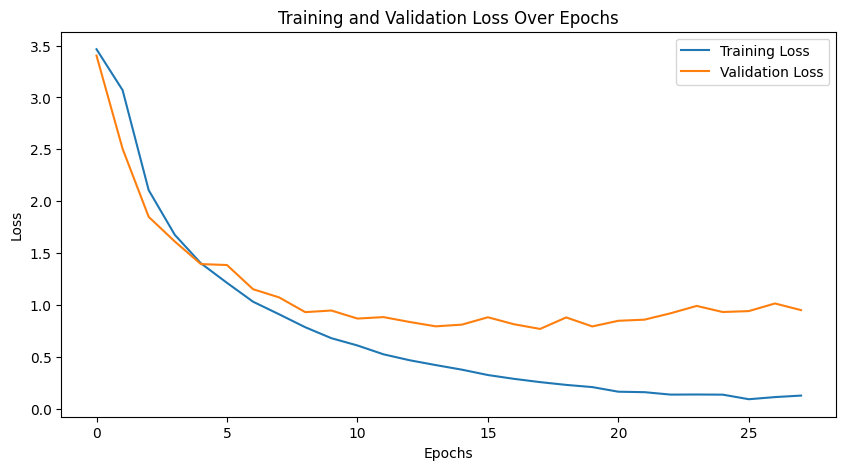

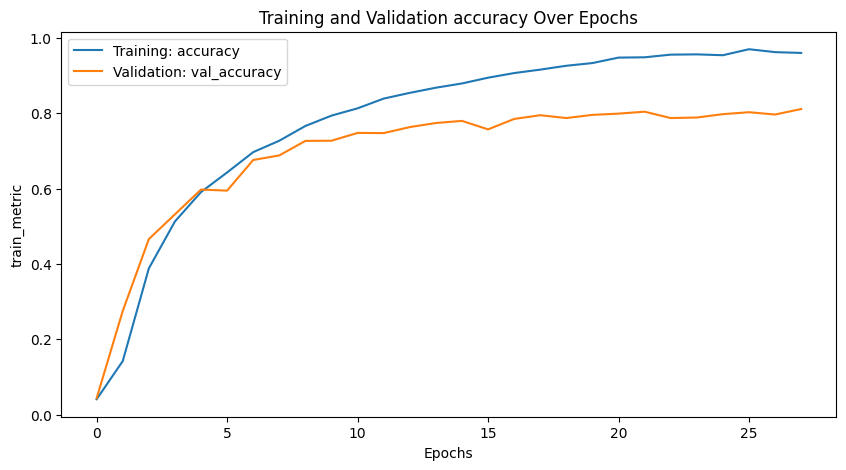

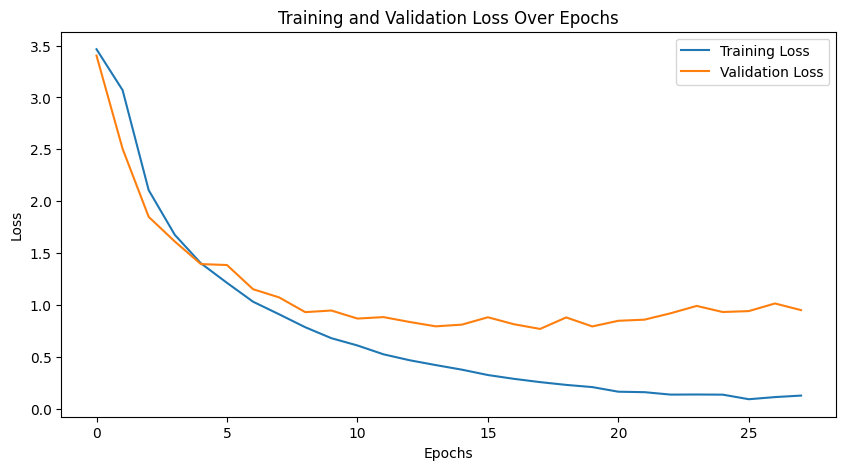

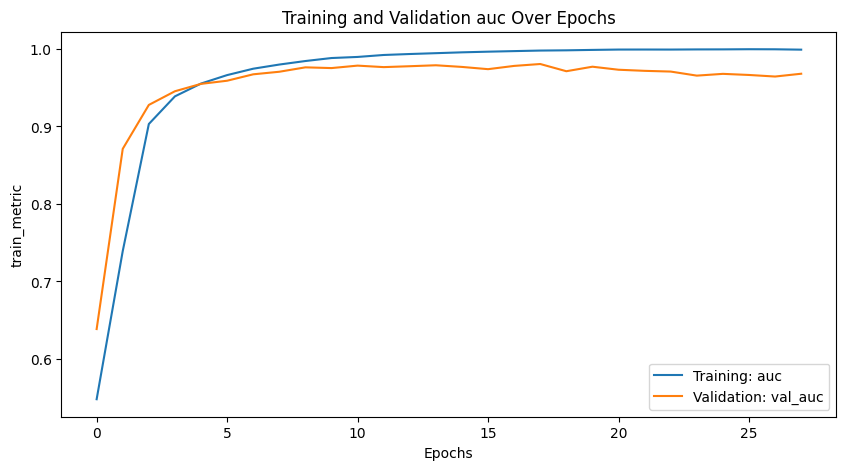

In [15]:
def plot_training_history(history, train_loss='loss', train_metric='accuracy', val_loss='val_loss', val_metric='val_accuracy'):

    #Loss
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_loss], label='Training Loss')
    plt.plot(history.history[val_loss], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Metrics
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_metric], label=f"Training: {train_metric}")
    plt.plot(history.history[val_metric], label=f"Validation: {val_metric}")
    plt.title(f'Training and Validation {train_metric} Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel(f'train_metric')
    plt.legend()
    plt.show()

plot_training_history(history, train_loss='loss', train_metric='accuracy', val_loss='val_loss', val_metric='val_accuracy')

plot_training_history(history, train_loss='loss', train_metric='auc', val_loss='val_loss', val_metric='val_auc')



In [16]:
val_loss, sparse_categorical_accuracy, auc = model.evaluate(val_ds, verbose=0)
print(f"Loss: {val_loss}")
print(f"Accuracy: {sparse_categorical_accuracy}")
print(f"AUC: {auc}")

Loss: 0.769452691078186
Accuracy: 0.7946428656578064
AUC: 0.9805189371109009


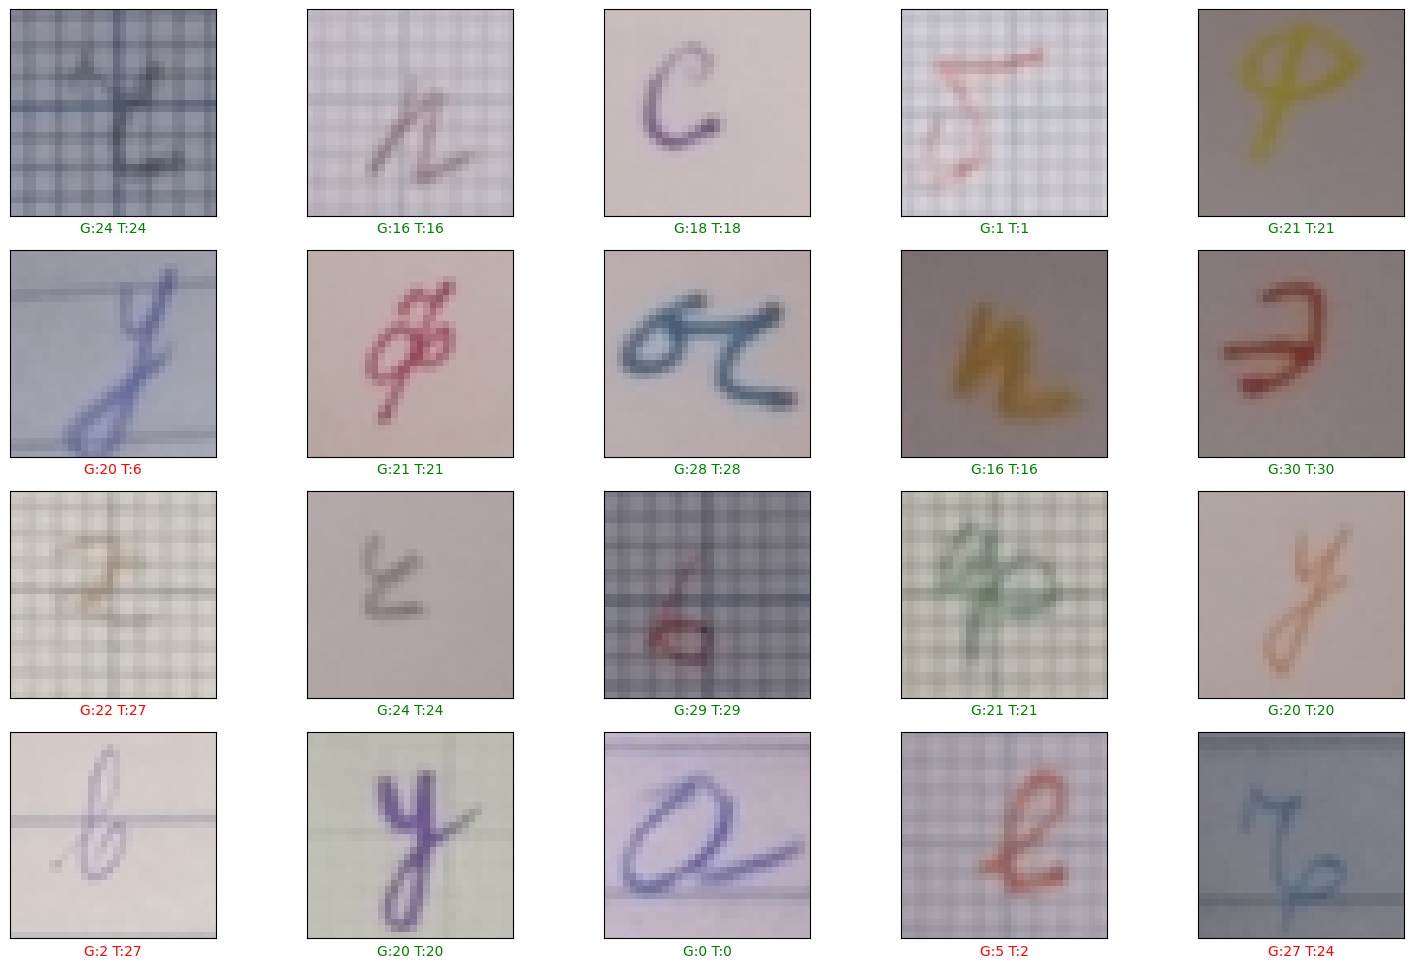

In [17]:
def show_predictions(X_test, y_test, model, num_examples=20):
    indices = np.random.choice(len(X_test), num_examples, replace=False)
    plt.figure(figsize=(15, 12))
    for i, idx in enumerate(indices):
        img = X_test[idx]
        true_label = y_test[idx]         
        pred = model.predict(img[np.newaxis, ...], verbose=0)
        pred_label = np.argmax(pred)

        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(img)

       
        color = 'green' if pred_label == true_label else 'red'
        plt.xlabel(f'G:{true_label} T:{pred_label}', color=color)

    plt.tight_layout()
    plt.show()


show_predictions(X_test, y_test, model)